In [1]:
import os, time
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping

print("Input folders:", os.listdir("../input"))




2026-05-06 10:22:29.124779: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778062949.138014      55 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778062949.142211      55 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-06 10:22:29.157697: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Input folders: ['sample_submission.csv', 'description.md', 'test.zip', 'train.csv', 'sample_submission.csv.zip', 'test', 'train.zip', 'aerial-cactus-identification', 'train', 'train.csv.zip']


In [2]:
# paths to data
train_path = "../input/train/train"
test_path = "../input/test/test"
train_csv = "../input/train.csv"
sample_sub = "../input/sample_submission.csv"




In [3]:
# load labels and build a filename‑to‑label dictionary
label_df = pd.read_csv(train_csv)
label_df = label_df.sort_values("id")
label_map = dict(
    zip(label_df["id"].astype(str), label_df["has_cactus"].astype(int).values)
)

# load training images
train_images = []
train_labels = []

for fname in tqdm(sorted(os.listdir(train_path))):
    img_path = os.path.join(train_path, fname)
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if img is None:
        continue  # skip unreadable files
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert to RGB for Keras
    train_images.append(img)
    train_labels.append(label_map.get(fname, 0))

X = np.stack(train_images).astype("float32") / 255.0  # shape (N,32,32,3)
Y = np.array(train_labels).astype("float32")  # shape (N,)




100%|██████████| 14176/14176 [00:01<00:00, 10085.06it/s]


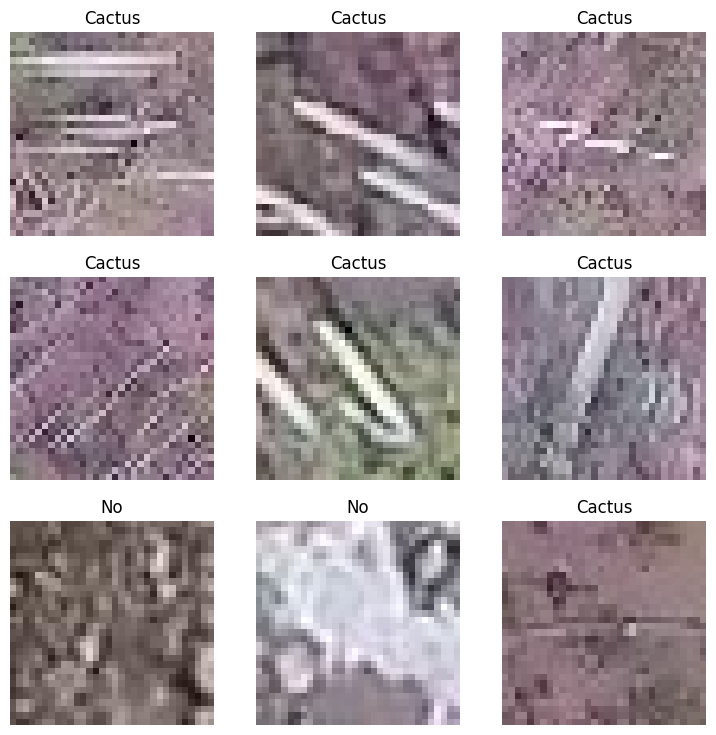

In [4]:
# optional quick visual check (first 9 images)
plt.figure(figsize=(9, 9))
for i in range(min(9, len(X))):
    plt.subplot(3, 3, i + 1)
    plt.axis("off")
    plt.title("Cactus" if Y[i] == 1 else "No")
    plt.imshow(X[i])
plt.show()




In [5]:
# load test images
test_images = []
test_ids = []

for fname in tqdm(sorted(os.listdir(test_path))):
    img_path = os.path.join(test_path, fname)
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    test_images.append(img)
    test_ids.append(fname)

X_test = np.stack(test_images).astype("float32") / 255.0  # shape (M,32,32,3)




100%|██████████| 3326/3326 [00:01<00:00, 2206.12it/s]


In [6]:
# build the model (the deeper architecture from the original script)
model = Sequential(
    [
        Conv2D(
            128,
            kernel_size=3,
            padding="same",
            activation="relu",
            input_shape=(32, 32, 3),
        ),
        MaxPooling2D(pool_size=2, strides=1),
        Dropout(0.2),
        Conv2D(64, kernel_size=3, padding="same", activation="relu"),
        MaxPooling2D(pool_size=2, strides=1),
        Dropout(0.2),
        Conv2D(32, kernel_size=3, padding="same", activation="relu"),
        MaxPooling2D(pool_size=2, strides=1),
        Dropout(0.2),
        Conv2D(16, kernel_size=3, padding="same", activation="relu"),
        MaxPooling2D(pool_size=2, strides=1),
        Dropout(0.2),
        Flatten(),
        Dense(256, activation="relu"),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dropout(0.4),
        Dense(1, activation="sigmoid"),
    ]
)
model.summary()




/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-06 10:22:39.002822: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1778062959.003251      55 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:46:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 31, 31, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 29, 29, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 29, 29, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,355,249 (12.80 MB)

 Trainable params: 3,355,249 (12.80 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = EarlyStopping(min_delta=0.001, patience=5, restore_best_weights=True)
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

start = time.time()
history = model.fit(
    X,
    Y,
    batch_size=256,
    validation_split=0.2,
    epochs=100,
    callbacks=[early_stop],
    verbose=2,
)
elapsed = time.time() - start
print(f"Training completed in {int(elapsed//60)} min {int(elapsed%60)} sec")




Epoch 1/100


I0000 00:00:1778062961.508250     111 service.cc:148] XLA service 0x7f50e8015d10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778062961.508278     111 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-05-06 10:22:41.546990: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778062961.768236     111 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-05-06 10:22:42.855869: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1851', 24 bytes spill stores, 24 bytes spill loads

2026-05-06 10:22:44.147350: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2689_0', 112 bytes spi

45/45 - 22s - 492ms/step - accuracy: 0.8249 - loss: 0.3727 - val_accuracy: 0.9365 - val_loss: 0.1763
Epoch 2/100
45/45 - 1s - 18ms/step - accuracy: 0.9375 - loss: 0.1694 - val_accuracy: 0.9238 - val_loss: 0.1929
Epoch 3/100
45/45 - 1s - 19ms/step - accuracy: 0.9438 - loss: 0.1577 - val_accuracy: 0.9489 - val_loss: 0.1704
Epoch 4/100
45/45 - 1s - 19ms/step - accuracy: 0.9640 - loss: 0.1077 - val_accuracy: 0.9647 - val_loss: 0.1108
Epoch 5/100
45/45 - 1s - 28ms/step - accuracy: 0.9658 - loss: 0.0956 - val_accuracy: 0.9527 - val_loss: 0.1325
Epoch 6/100
45/45 - 1s - 19ms/step - accuracy: 0.9713 - loss: 0.0831 - val_accuracy: 0.9520 - val_loss: 0.1190
Epoch 7/100
45/45 - 1s - 18ms/step - accuracy: 0.9647 - loss: 0.0982 - val_accuracy: 0.9055 - val_loss: 0.2347
Epoch 8/100
45/45 - 1s - 18ms/step - accuracy: 0.9632 - loss: 0.1002 - val_accuracy: 0.9743 - val_loss: 0.0758
Epoch 9/100
45/45 - 1s - 18ms/step - accuracy: 0.9802 - loss: 0.0557 - val_accuracy: 0.9753 - val_loss: 0.0701
Epoch 10/10

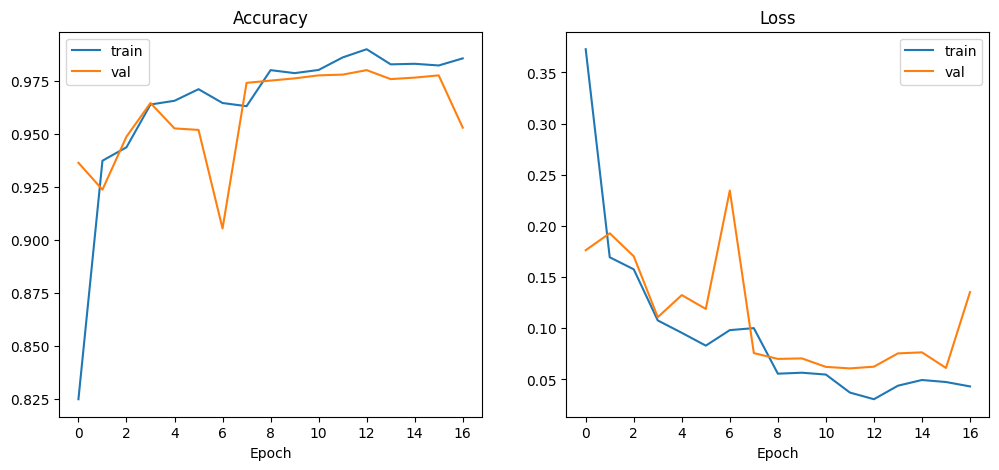

In [8]:
# plot training curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()




In [9]:
# predict on test set and create submission file
preds = model.predict(X_test, batch_size=256).ravel()
submission = pd.DataFrame({"id": test_ids, "has_cactus": preds})
submission_path = "cactus_submission.csv"
submission.to_csv(submission_path, index=False)
print(f"Submission saved to {submission_path}, shape {submission.shape}")

 1/13 ━━━━━━━━━━━━━━━━━━━━ 5s 424ms/step

2026-05-06 10:23:17.352712: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_85_0', 168 bytes spill stores, 168 bytes spill loads

2026-05-06 10:23:17.492160: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_85', 12 bytes spill stores, 12 bytes spill loads

2026-05-06 10:23:18.602592: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_92', 12 bytes spill stores, 12 bytes spill loads



13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 236ms/step
Submission saved to cactus_submission.csv, shape (3325, 2)
